Loaded datasets:
Control shape: (125094, 14)
Test shape: (150288, 14)

--- Processing Control group ---
Mapped process steps to numeric order.
Sorted data by client, visit, and time.
Calculated previous step for each event.
Flagged backward movements as errors.
Calculated error rate per step:
  process_step  error_rate_control
0      confirm            0.000000
1        start            0.131913
2       step_1            0.083187
3       step_2            0.091594
4       step_3            0.008379

--- Processing Test group ---
Mapped process steps to numeric order.
Sorted data by client, visit, and time.
Calculated previous step for each event.
Flagged backward movements as errors.
Calculated error rate per step:
  process_step  error_rate_test
0      confirm         0.000000
1        start         0.251590
2       step_1         0.095904
3       step_2         0.074059
4       step_3         0.001468

--- Final step-by-step comparison ---
  process_step  error_rate_control  error_ra

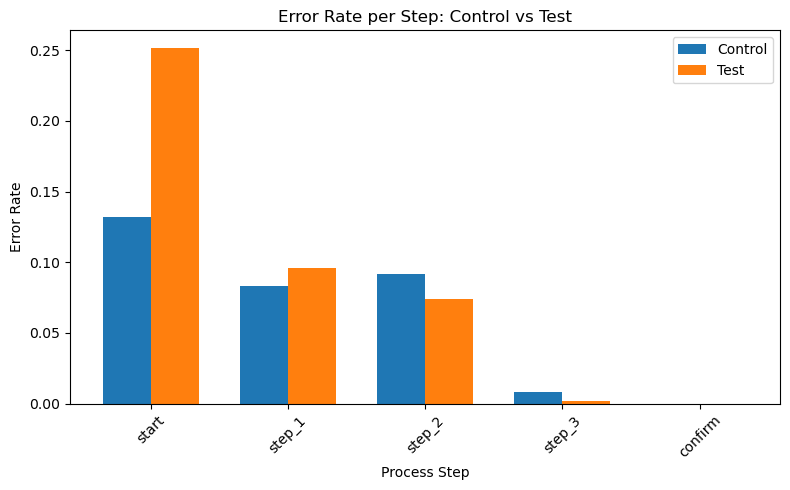

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load the updated datasets
df_control = pd.read_csv('df_control_updated.csv')
df_test = pd.read_csv('df_test_updated.csv')

print("Loaded datasets:")
print("Control shape:", df_control.shape)
print("Test shape:", df_test.shape)

# Step 2: Define the funnel order
step_order = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}

# Step 3: Function to calculate error rate per step
def error_rate_per_step(df, label):
    df = df.copy()

    print(f"\n--- Processing {label} group ---")

    # Convert steps to numeric order
    df['step_num'] = df['process_step'].map(step_order)
    print("Mapped process steps to numeric order.")

    # Convert datetime and sort events correctly
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    print("Sorted data by client, visit, and time.")

    # Get previous step within each session
    df['prev_step'] = df.groupby(['client_id', 'visit_id'])['step_num'].shift(1)
    print("Calculated previous step for each event.")

    # Flag errors: going backwards
    df['error'] = df['step_num'] < df['prev_step']
    print("Flagged backward movements as errors.")

    # Calculate error rate per step
    step_errors = df.groupby('process_step')['error'].mean().reset_index()
    step_errors.columns = ['process_step', f'error_rate_{label.lower()}']

    print("Calculated error rate per step:")
    print(step_errors)

    return step_errors

# Step 4: Calculate per-step error rates for both groups
control_step_errors = error_rate_per_step(df_control, "Control")
test_step_errors = error_rate_per_step(df_test, "Test")

# Step 5: Merge results for comparison
comparison = control_step_errors.merge(
    test_step_errors,
    on='process_step',
    how='outer'
)

# Step 6: Order steps correctly
order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
comparison = comparison.set_index('process_step').loc[order].reset_index()

print("\n--- Final step-by-step comparison ---")
print(comparison)

# Step 7: Plot side-by-side bars
x = np.arange(len(comparison['process_step']))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, comparison['error_rate_control'], width, label='Control')
plt.bar(x + width/2, comparison['error_rate_test'], width, label='Test')

plt.xticks(x, comparison['process_step'], rotation=45)
plt.title('Error Rate per Step: Control vs Test')
plt.ylabel('Error Rate')
plt.xlabel('Process Step')
plt.legend()

plt.tight_layout()
plt.show()

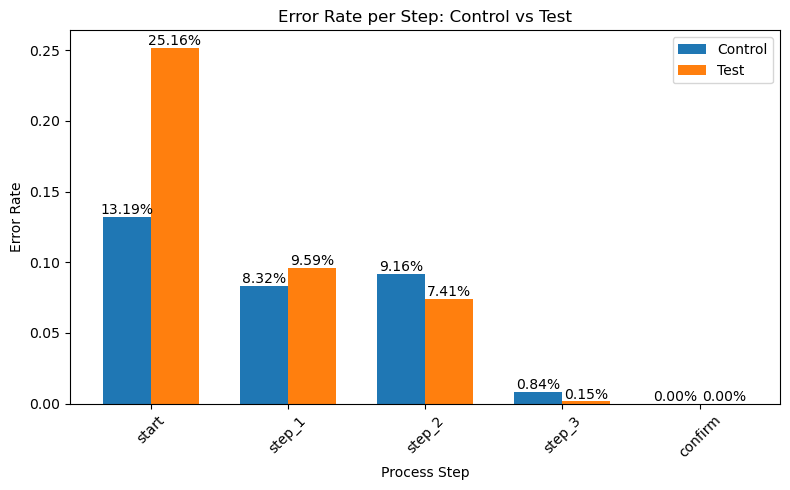

In [3]:
x = np.arange(len(comparison['process_step']))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width/2, comparison['error_rate_control'], width, label='Control')
bars2 = plt.bar(x + width/2, comparison['error_rate_test'], width, label='Test')

plt.xticks(x, comparison['process_step'], rotation=45)
plt.title('Error Rate per Step: Control vs Test')
plt.ylabel('Error Rate')
plt.xlabel('Process Step')
plt.legend()

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.002, f'{height:.2%}', ha='center')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.002, f'{height:.2%}', ha='center')

plt.tight_layout()
plt.show()

In [4]:
# Hypothesis testing

# H0 (null hypothesis):
# There is NO difference in error rate between Control and Test

# H1 (alternative hypothesis):
# There IS a difference in error rate between Control and Test

In [5]:
def session_error_rate(df):
    df = df.copy()
    
    step_order = {
        'start': 0,
        'step_1': 1,
        'step_2': 2,
        'step_3': 3,
        'confirm': 4
    }
    
    df['step_num'] = df['process_step'].map(step_order)
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    
    df['prev_step'] = df.groupby(['client_id', 'visit_id'])['step_num'].shift(1)
    df['error'] = df['step_num'] < df['prev_step']
    
    # session-level error
    session_errors = df.groupby(['client_id', 'visit_id'])['error'].any()
    
    total_sessions = session_errors.count()
    total_errors = session_errors.sum()
    
    error_rate = total_errors / total_sessions
    
    return total_errors, total_sessions, error_rate

In [11]:
control_errors, control_n, control_rate = session_error_rate(df_control)
test_errors, test_n, test_rate = session_error_rate(df_test)

print(f"Control: {control_errors} / {control_n} = {control_rate:.2%}")
print(f"Test: {test_errors} / {test_n} = {test_rate:.2%}")

Control: 6586 / 32232 = 20.43%
Test: 9952 / 37193 = 26.76%


In [7]:
from statsmodels.stats.proportion import proportions_ztest

# successes = number of sessions with error
successes = [control_errors, test_errors]

# total observations
samples = [control_n, test_n]

z_stat, p_value = proportions_ztest(successes, samples)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -19.50968204683044
P-value: 9.084536726144855e-85


In [8]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The difference is statistically significant.")
else:
    print("Fail to reject H0: No significant difference detected.")

Reject H0: The difference is statistically significant.


In [9]:
if test_rate < control_rate:
    print("Test improves user experience (fewer errors).")
else:
    print("Interpretation: The Test group shows a significantly higher error rate, indicating a worse user experience.")

Interpretation: The Test group shows a significantly higher error rate, indicating a worse user experience.
